<a href="https://colab.research.google.com/github/Sneha8126/Sneha-copy-of-Sample-ML-Submission-Template/blob/main/Sneha_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual

Name : Sneha

Branch : CSE - C

Roll Number : 51420802724

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Accurate taxi fare estimation is essential for ensuring transparent pricing, improving customer satisfaction, and supporting efficient transportation services. Taxi trip prices are influenced by various factors such as trip distance, travel duration, traffic conditions, weather, passenger count, and time of travel, making manual fare estimation difficult and inconsistent. The objective of this project is to develop a machine learning regression model that predicts taxi trip prices based on these trip-related features. By analyzing historical trip data and identifying the key factors affecting fare prices, the model aims to provide accurate fare predictions that can assist taxi service providers in pricing trips fairly and optimizing their operations.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/taxi_trip_pricing.csv')

### Dataset First View

In [5]:
# Dataset First Look
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 11


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


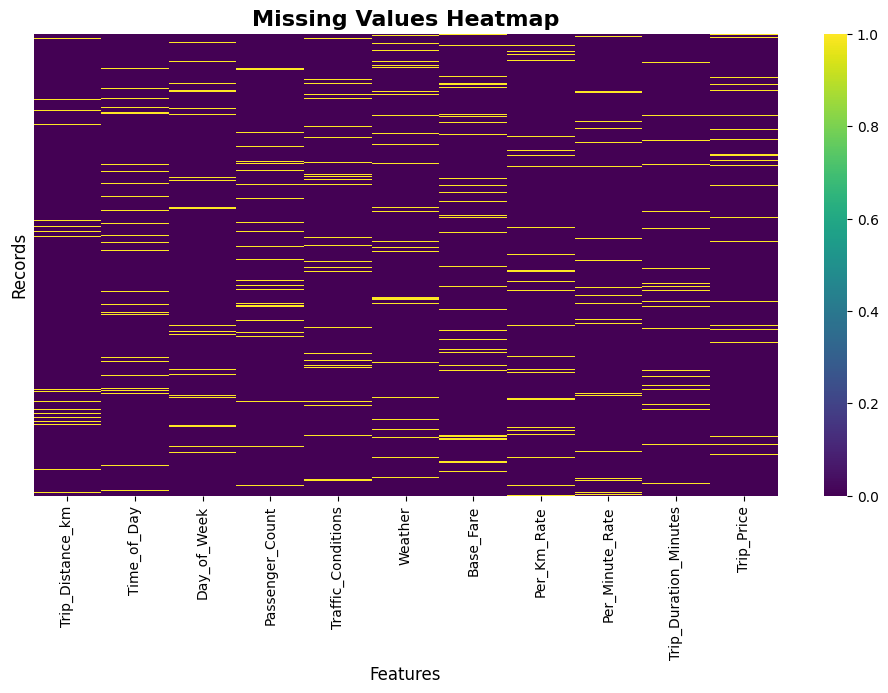

In [10]:
# Missing Values Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='viridis',
    yticklabels=False
)

plt.title('Missing Values Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Records', fontsize=12)

plt.show()

### What did you know about your dataset?

* The dataset contains historical taxi trip information and is designed for predicting taxi trip prices.

* It consists of 1,000 records and 11 features, including both numerical and categorical variables.

* The target variable is Trip-Price, making this a supervised machine learning regression problem.

* The dataset includes important trip-related features such as trip distance, trip duration, passenger count, traffic conditions, weather, time of day, day of the week, base fare, per-kilometer rate, and per-minute rate.

* Both numerical and categorical features are present, so preprocessing steps such as handling missing values and encoding categorical variables are required.

* A few columns contain missing values, which need to be treated before model training.

* The dataset is suitable for Exploratory Data Analysis (EDA) to identify relationships between trip characteristics and taxi fares.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


### Variables Description

* **Trip_Distance_km:** Represents the total distance traveled during the taxi trip in kilometers.

* **Time_of_Day:** Indicates the time period when the trip took place (e.g., Morning, Afternoon, Evening, Night).

* **Day_of_Week:** Specifies the day on which the taxi trip occurred.

* **Passenger_Count:** Shows the number of passengers traveling in the taxi.

* **Traffic_Conditions:** Describes the traffic level during the trip (e.g., Low, Medium, High).

* **Weather:** Represents the weather conditions during the trip, such as Clear, Rainy, or Snowy.

* **Base_Fare:** The fixed starting fare charged for the taxi trip before additional costs.

* **Per_Km_Rate:** The fare charged for every kilometer traveled.

* **Per_Minute_Rate:** The fare charged for each minute of trip duration.

* **Trip_Duration_Minutes:** Indicates the total time taken to complete the taxi trip in minutes.

* **Trip_Price (Target Variable):** Represents the final fare of the taxi trip.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.nunique()

,0
Trip_Distance_km,867
Time_of_Day,4
Day_of_Week,2
Passenger_Count,4
Traffic_Conditions,3
Weather,3
Base_Fare,290
Per_Km_Rate,150
Per_Minute_Rate,41
Trip_Duration_Minutes,917


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
df.shape

(1000, 11)

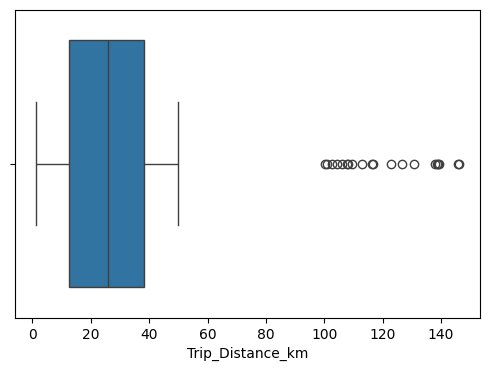

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Trip_Distance_km'])
plt.show()

In [16]:
# Write your code to make your dataset analysis ready.

df.dropna(subset=['Trip_Price'],inplace=True)

num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
  if col!='Trip_Price':
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

In [17]:
# Verify missing values
print(df.isnull().sum())

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


### What all manipulations have you done and insights you found?

* Checked the dataset for duplicate records to ensure data consistency and avoid redundant observations.

* Identified missing values in the dataset and calculated their percentage for each column.

* Filled missing values in categorical columns using the mode and in the numerical column using the median to preserve the data distribution.

* Verified that all missing values were handled successfully before proceeding with further analysis.

* Reviewed the dataset structure and data quality to ensure it was ready for exploratory data analysis and machine learning.

* After data wrangling, the dataset became cleaner, more consistent, and suitable for building an accurate freight cost prediction model.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

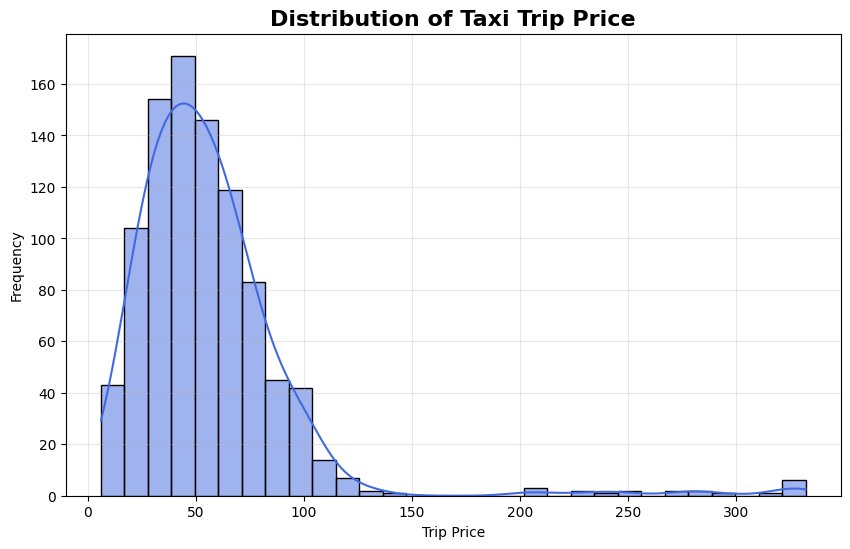

In [18]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Trip_Price',
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title('Distribution of Taxi Trip Price', fontsize=16, fontweight='bold')
plt.xlabel('Trip Price')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is suitable for visualizing the distribution of the target variable (Trip-Price). It helps identify the overall spread, central tendency, skewness, and potential outliers in taxi fares.

##### 2. What is/are the insight(s) found from the chart?

* Shows how taxi trip prices are distributed.

* Helps identify whether most fares are concentrated within a specific price range.

* Reveals whether the distribution is symmetric or skewed.

* Highlights possible high-value fare outliers.

##### 3. Will the gained insights help creating a positive business impact?

* Helps taxi companies understand common fare ranges.

* Useful for identifying unusually expensive trips that may require validation.
* Supports pricing analysis and demand forecasting.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* A small number of very high-priced trips (outliers) may indicate inconsistent pricing, which could reduce customer trust if fares appear unpredictable.

* If a large proportion of trips are concentrated in the lower fare range, it may suggest that the business relies mainly on short-distance trips, limiting overall revenue growth.

#### Chart - 2

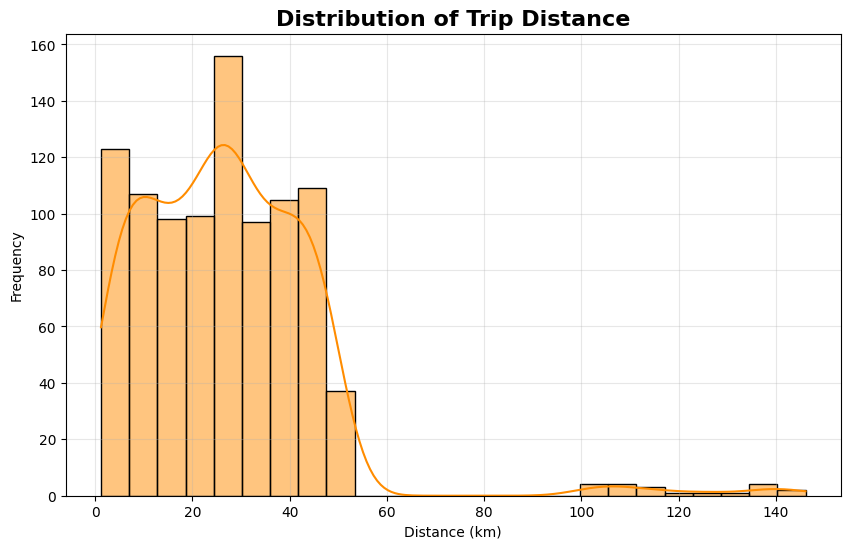

In [19]:
# Chart - 2 visualization code
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Trip_Distance_km',
    bins=25,
    kde=True,
    color='darkorange'
)

plt.title('Distribution of Trip Distance', fontsize=16, fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram effectively shows how trip distances are distributed across all taxi rides and whether short or long trips are more common.

##### 2. What is/are the insight(s) found from the chart?

* Most taxi trips may fall within a limited distance range.
* Long-distance trips are less frequent.

##### 3. Will the gained insights help creating a positive business impact?

* Supports fuel consumption and operational planning.
* Assists in designing distance-based pricing strategies.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* A high concentration of short-distance trips may limit overall revenue, as these trips generate lower fares compared to longer journeys.
* If long-distance trips are very few, it may indicate missed opportunities to increase revenue through higher-value rides.

#### Chart - 3

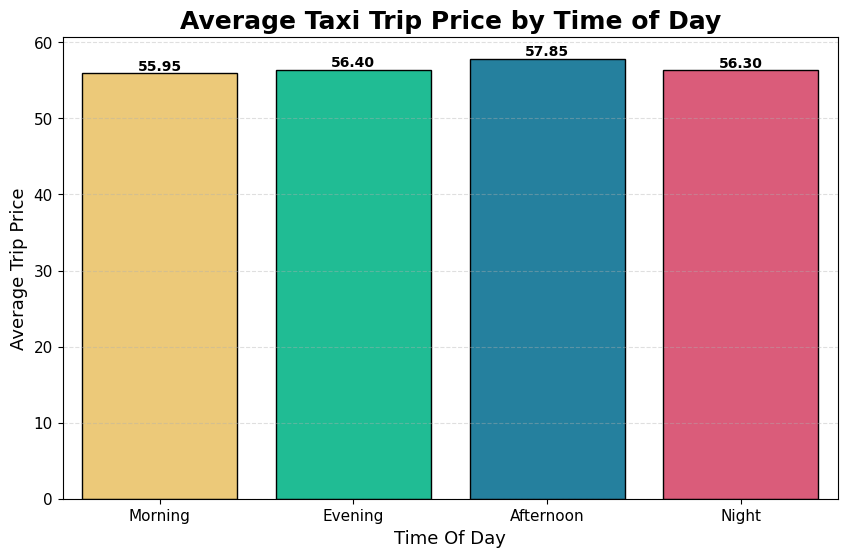

In [20]:
from matplotlib.lines import lineStyles
# Chart - 3 visualization code

# Average Trip Price by Time of Day

plt.figure(figsize=(10,6))
colors = ['#FFD166', '#06D6A0', '#118AB2', '#EF476F']
ax = sns.barplot(
    data=df,
    x='Time_of_Day',
    y='Trip_Price',
    estimator='mean',
    hue='Time_of_Day',
    palette=colors,
    edgecolor='black',
    legend=False,
    errorbar=None
)

for container in ax.containers:
  ax.bar_label(container,fmt='%.2f',fontsize=10,fontweight='bold')

plt.title('Average Taxi Trip Price by Time of Day',fontsize=18,fontweight='bold')
plt.xlabel('Time Of Day',fontsize=13)
plt.ylabel('Average Trip Price',fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.show()

##### 1. Why did you pick the specific chart?

* A bar chart is ideal for comparing the average trip price across different time periods of the day.
* It clearly highlights which time of day generates higher or lower taxi fares.
* It allows easy comparison between multiple categorical groups.

##### 2. What is/are the insight(s) found from the chart?

* The average taxi fare varies across different times of the day.
* Time of travel appears to influence fare pricing, likely due to changes in demand and traffic conditions.
* The chart helps identify peak periods when taxi fares are generally higher.

##### 3. Will the gained insights help creating a positive business impact?

* Taxi companies can implement dynamic pricing during high-demand periods.
* Drivers can be scheduled more efficiently during time slots with higher average fares.
* Customers can be informed about expected fare variations throughout the day.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* Time periods with consistently lower average fares may generate less revenue for drivers and taxi operators.
* If too many trips occur during low-fare periods, overall profitability may decrease.

#### Chart - 4

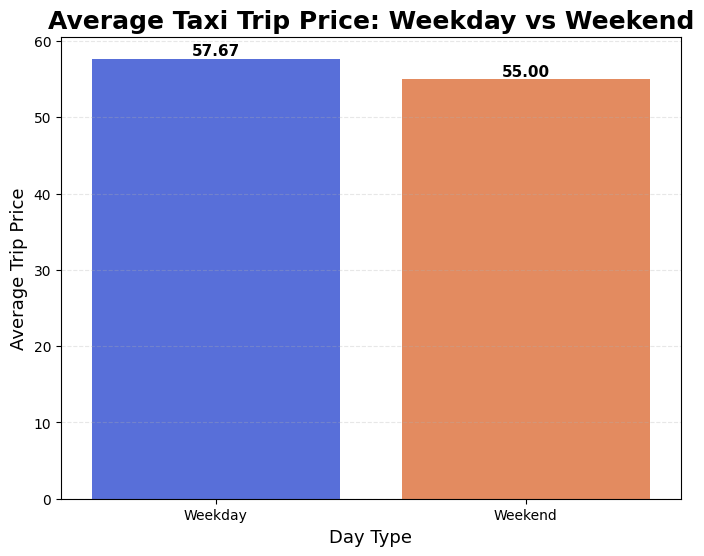

In [21]:
# Chart - 4 visualization code

# Chart 4: Average Trip Price by Day of Week

plt.figure(figsize=(8,6))

colors = ['#4361EE', '#F9844A']

ax = sns.barplot(
    data=df,
    x='Day_of_Week',
    y='Trip_Price',
    estimator='mean',
    hue='Day_of_Week',
    palette=colors,
    legend=False,
    errorbar=None
)

# Value Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=11, fontweight='bold')

plt.title('Average Taxi Trip Price: Weekday vs Weekend',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Day Type', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A bar chart is ideal for comparing the average trip prices between two categories: Weekday and Weekend.
* It provides a clear visual comparison of average fares across different day types.


##### 2. What is/are the insight(s) found from the chart?

* The average taxi trip price differs between Weekdays and Weekends.
* The variation suggests that customer demand and trip characteristics change based on the day type.
* Day type is an important factor that can influence taxi pricing.

##### 3. Will the gained insights help creating a positive business impact?

* Taxi operators can optimize driver availability based on the day type with higher average fares.
* Businesses can implement dynamic pricing during periods with higher demand.
* Promotional offers can be introduced on lower-demand days to increase bookings.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* If one day type consistently generates lower average fares, it may reduce overall revenue.
* Depending heavily on only one day type for higher earnings may create inconsistent revenue throughout the week.

#### Chart - 5

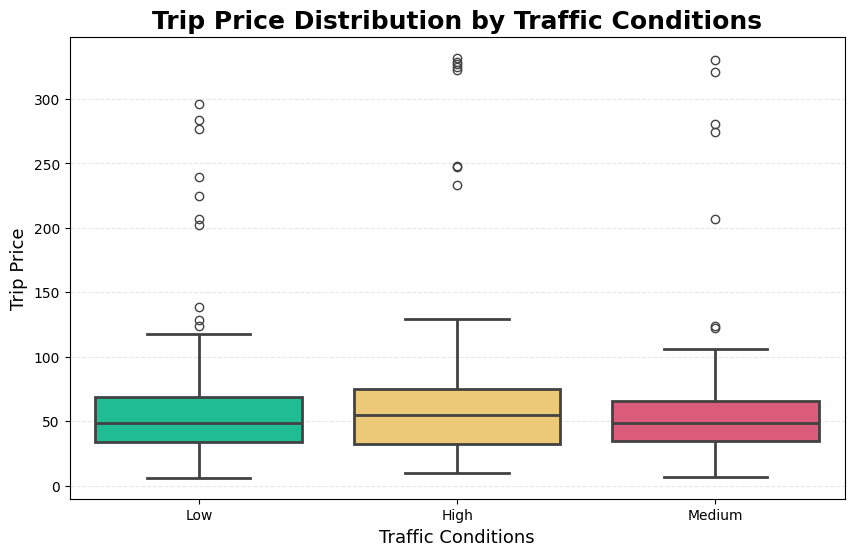

In [22]:
# Chart - 5 visualization code

# Chart 5: Trip Price Distribution by Traffic Conditions

plt.figure(figsize=(10,6))
colors = ['#06D6A0', '#FFD166', '#EF476F']
ax = sns.boxplot(
    data=df,x='Traffic_Conditions',y='Trip_Price',hue='Traffic_Conditions',palette=colors,legend=False,linewidth=2
)

plt.title('Trip Price Distribution by Traffic Conditions',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Traffic Conditions', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

* A box plot is ideal for comparing the distribution of trip prices across different traffic conditions.
* It clearly displays the median, quartiles, spread, and outliers for each traffic category.
* It helps identify whether traffic conditions significantly affect taxi fares.

##### 2. What is/are the insight(s) found from the chart?

* Trip prices vary across different traffic conditions.

* Higher traffic conditions may be associated with greater fare variability due to longer travel times.

* The spread of trip prices differs between traffic categories, indicating changes in fare consistency.

##### 3. Will the gained insights help creating a positive business impact?


* Taxi companies can improve fare estimation by considering traffic conditions.
* Drivers can be assigned more efficiently during high-traffic periods.
* Better traffic-based planning can improve customer satisfaction and operational efficiency.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* Heavy traffic can increase trip duration, reducing the number of trips a driver can complete in a day.
* Frequent traffic congestion can increase fuel consumption and operating costs, reducing profitability.
* If customers consistently face higher fares due to traffic, they may switch to alternative transportation options.

#### Chart - 6

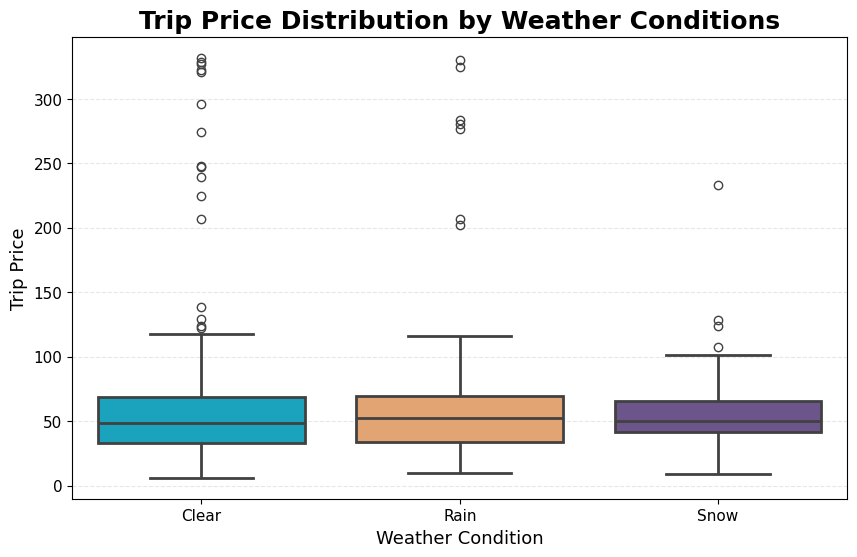

In [23]:
# Chart - 6 visualization code

# Chart 6: Trip Price Distribution by Weather Conditions

plt.figure(figsize=(10,6))

colors = ['#00B4D8', '#F4A261', '#6A4C93']   # Clear, Rain, Snow

ax = sns.boxplot(
    data=df,
    x='Weather',
    y='Trip_Price',
    hue='Weather',
    palette=colors,
    legend=False,
    linewidth=2,
    showfliers=True
)

plt.title('Trip Price Distribution by Weather Conditions',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Weather Condition', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A box plot is the best choice for comparing trip price distributions across different weather conditions.

* It helps identify whether weather has a significant impact on taxi fares.

* It enables easy comparison of fare variability between different weather conditions.




##### 2. What is/are the insight(s) found from the chart?

* Trip prices vary across different weather conditions.
* Some weather conditions show a higher median trip price, indicating increased travel costs.
* The spread of trip prices differs among weather categories, suggesting that weather influences fare variability.

##### 3. Will the gained insights help creating a positive business impact?

* Taxi companies can improve fare prediction by including weather as a pricing factor.
* Fleet managers can deploy more vehicles during adverse weather when demand is likely to increase.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* Severe weather conditions may reduce the number of customers willing to travel, decreasing trip volume.
* Adverse weather can increase trip duration and operational costs, lowering overall efficiency.

#### Chart - 7

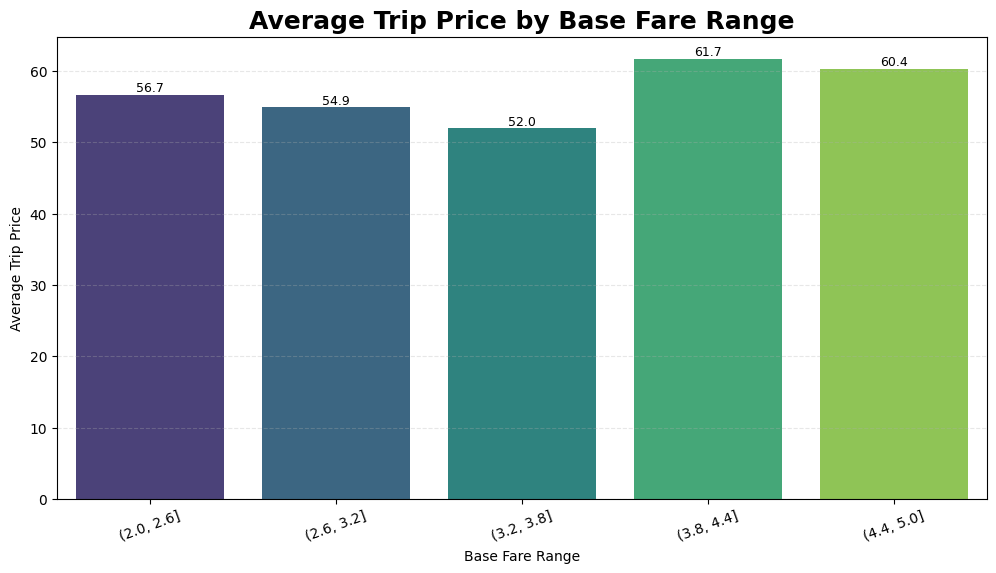

In [60]:
# Chart - 7 visualization code

# Chart 7: Average Trip Price by Base Fare

plt.figure(figsize=(12,6))

# Create Base Fare groups
df['Base_Fare_Group'] = pd.cut(
    df['Base_Fare'],
    bins=5,
    precision=1
)

ax = sns.barplot(
    data=df,
    x='Base_Fare_Group',
    y='Trip_Price',
    estimator='mean',
    hue='Base_Fare_Group',
    palette='viridis',
    legend=False,
    errorbar=None
)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.title('Average Trip Price by Base Fare Range',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Base Fare Range')
plt.ylabel('Average Trip Price')

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


##### 1. Why did you pick the specific chart?

* A grouped bar chart effectively compares the average trip price across different base fare ranges.
* It helps visualize how changes in the base fare influence the final trip price.

##### 2. What is/are the insight(s) found from the chart?

* Average trip price changes across different base fare ranges.
* Higher base fare ranges generally correspond to higher average trip prices.
* Base fare is an important contributor to the overall taxi fare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Helps companies evaluate whether the current base fare structure is appropriate.
* Supports fair and transparent pricing policies.
* Very high base fares may discourage customers from booking taxis.
* An inconsistent relationship between base fare and total trip price may reduce customer trust.

#### Chart - 8

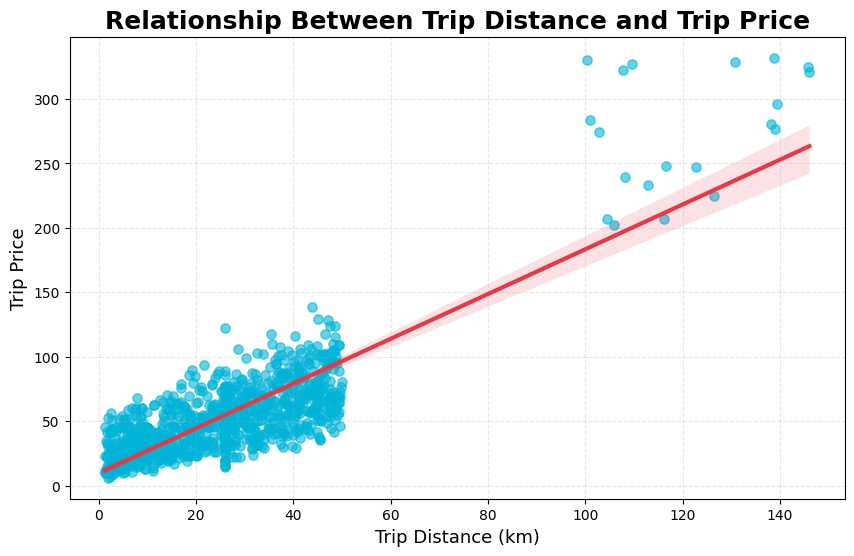

In [25]:
# Chart - 8 visualization code
# Chart 8: Trip Distance vs Trip Price

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Trip_Distance_km',
    y='Trip_Price',
    scatter_kws={
        'color':'#00B4D8',
        'alpha':0.6,
        's':45
    },
    line_kws={
        'color':'#E63946',
        'linewidth':3
    }
)

plt.title('Relationship Between Trip Distance and Trip Price',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Trip Distance (km)', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A scatter plot with a regression line is ideal for analyzing the relationship between two numerical variables.
* It helps visualize whether trip price increases as trip distance increases.
* The regression line clearly indicates the overall trend in the data.

##### 2. What is/are the insight(s) found from the chart?

* A positive relationship is expected between trip distance and trip price.
* As the trip distance increases, the overall trip price also tends to increase.
* The regression line helps confirm whether the relationship is strong and approximately linear.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Understanding the relationship between distance and fare helps improve pricing accuracy.
* It supports the development of reliable fare prediction models.

* Poor distance-based pricing can reduce customer satisfaction and affect repeat bookings.
* If the relationship between distance and price is inconsistent, customers may perceive the pricing as unfair.

#### Chart - 9

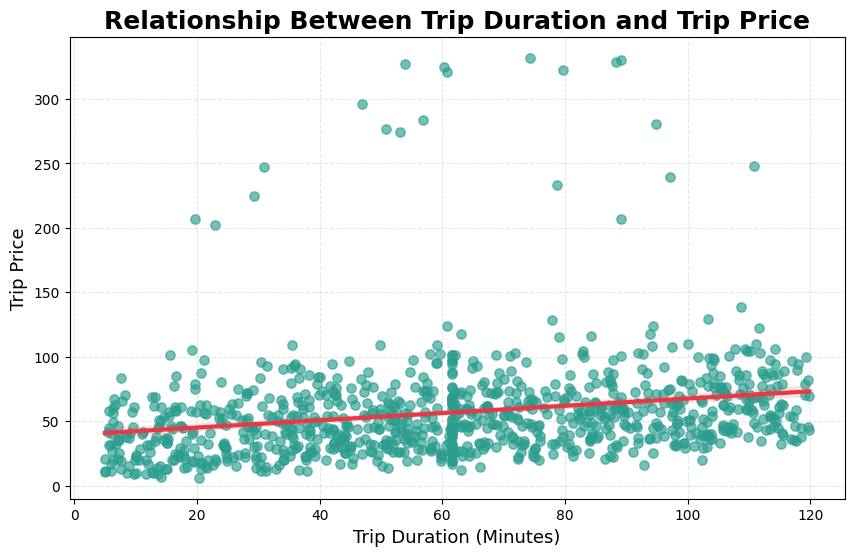

In [26]:
# Chart - 9 visualization code
# Chart 9: Trip Duration vs Trip Price

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Trip_Duration_Minutes',
    y='Trip_Price',
    scatter_kws={
        'color':'#2A9D8F',
        'alpha':0.65,
        's':45
    },
    line_kws={
        'color':'#E63946',
        'linewidth':3
    }
)

plt.title('Relationship Between Trip Duration and Trip Price',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Trip Duration (Minutes)', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A scatter plot with a regression line is ideal for studying the relationship between trip duration and trip price.
* It clearly shows whether longer trips generally result in higher fares.

##### 2. What is/are the insight(s) found from the chart?

* Trip price generally increases as trip duration increases.
* The regression line indicates the overall relationship between travel time and fare.
* Trip duration is an important factor influencing taxi fare prediction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Taxi companies can improve fare estimation by considering trip duration.
* Better understanding of travel time helps optimize pricing strategies.

* Longer trip durations caused by traffic congestion may reduce the number of trips a driver can complete, lowering daily revenue.
* If fares do not increase appropriately with trip duration, drivers may experience reduced profitability.

#### Chart - 10

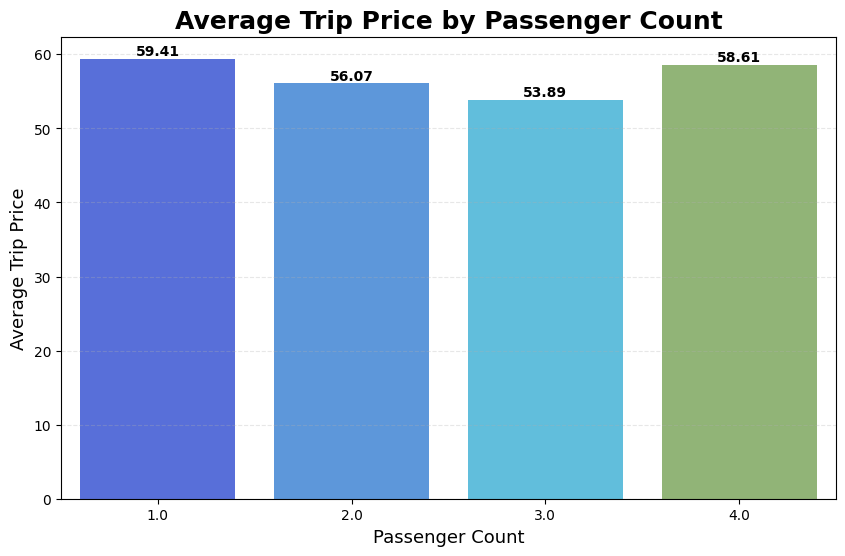

In [27]:
# Chart - 10 visualization code
# Chart 10: Average Trip Price by Passenger Count

plt.figure(figsize=(10,6))

colors = ['#4361EE','#4895EF','#4CC9F0','#90BE6D']

ax = sns.barplot(
    data=df,
    x='Passenger_Count',
    y='Trip_Price',
    estimator='mean',
    hue='Passenger_Count',
    palette=colors,
    legend=False,
    errorbar=None
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, fontweight='bold')

plt.title('Average Trip Price by Passenger Count',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Passenger Count', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A bar chart is ideal for comparing the average trip price across different passenger counts.
* It clearly shows whether the number of passengers has an impact on taxi fares.
* The chart helps identify trends in average pricing based on passenger count.

##### 2. What is/are the insight(s) found from the chart?

* The average trip price varies across different passenger counts.
* Some passenger groups have higher average fares than others.
* Passenger count may influence trip characteristics and overall fare.
* The chart highlights whether passenger count is an important feature for fare prediction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Taxi companies can better understand how passenger count relates to pricing.
* Understanding passenger trends can help optimize vehicle allocation and service planning.

* Passenger groups with consistently lower average fares may contribute less to overall revenue.
* If vehicle allocation does not match passenger demand, operational efficiency may decrease.

#### Chart - 11

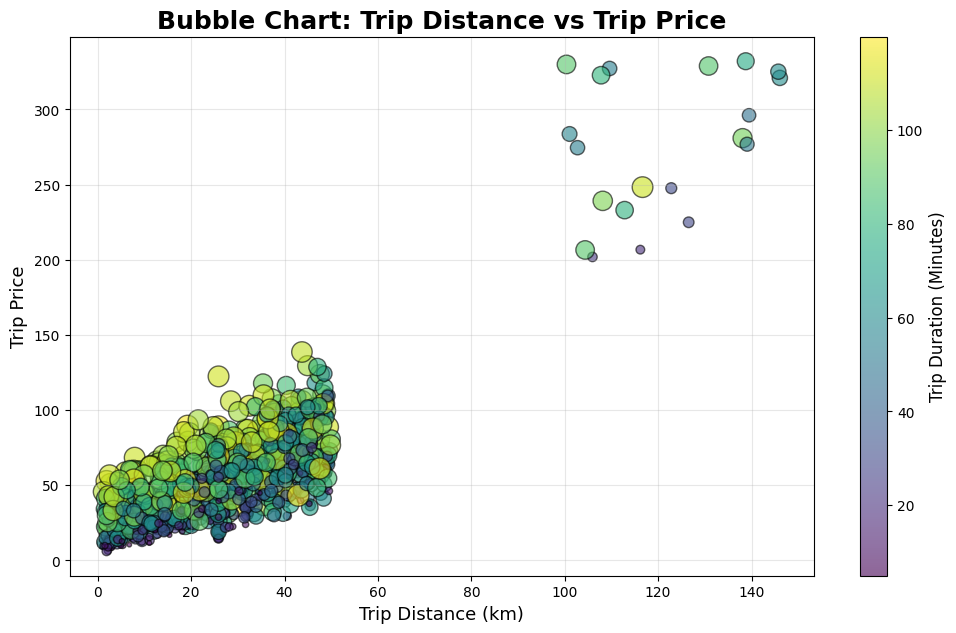

In [28]:
# Chart - 11 visualization code

plt.figure(figsize=(12,7))

plt.scatter(
    df['Trip_Distance_km'],
    df['Trip_Price'],
    s=df['Trip_Duration_Minutes']*2,
    c=df['Trip_Duration_Minutes'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black'
)

cbar = plt.colorbar()
cbar.set_label('Trip Duration (Minutes)', fontsize=12)

plt.title('Bubble Chart: Trip Distance vs Trip Price',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Trip Distance (km)', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A bubble chart displays three variables simultaneously.
* It helps analyze the combined effect of trip distance and duration on trip price.
* Bubble size makes it easy to identify longer trips.

##### 2. What is/are the insight(s) found from the chart?

* Trip prices generally increase with trip distance.
* Larger bubbles indicate longer trips, which are often associated with higher fares.
* The chart highlights the combined impact of distance and duration on taxi fares.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Helps improve fare estimation by considering both distance and duration.
* Supports better pricing strategies.
* Identifies trips that consume more time and resources.

* Long-duration trips with relatively low fares may reduce driver profitability.
* High variability in pricing for similar distances may affect customer trust.

#### Chart - 12

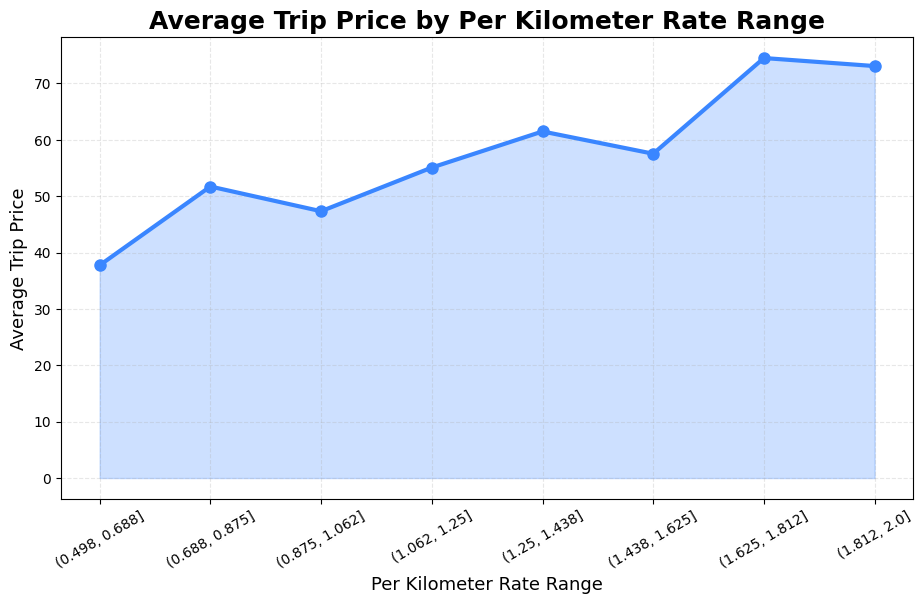

In [63]:
# Chart - 12 visualization code
# Chart 12: Average Trip Price by Per Km Rate Range

plt.figure(figsize=(11,6))

# Create groups
df['Per_Km_Rate_Group'] = pd.cut(df['Per_Km_Rate'], bins=8)

avg_price = df.groupby('Per_Km_Rate_Group',
                       observed=True)['Trip_Price'].mean().reset_index()

plt.plot(
    avg_price['Per_Km_Rate_Group'].astype(str),
    avg_price['Trip_Price'],
    marker='o',
    linewidth=3,
    markersize=8,
    color='#3A86FF'
)

plt.fill_between(
    avg_price['Per_Km_Rate_Group'].astype(str),
    avg_price['Trip_Price'],
    alpha=0.25,
    color='#3A86FF'
)

plt.title('Average Trip Price by Per Kilometer Rate Range',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Per Kilometer Rate Range', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)

plt.xticks(rotation=30)

plt.grid(linestyle='--', alpha=0.3)

plt.show()


##### 1. Why did you pick the specific chart?

* A line chart effectively shows how the average trip price changes across different per-kilometer rate ranges.
* It highlights pricing trends rather than individual observations.
* It is useful for identifying increasing or decreasing fare patterns.

##### 2. What is/are the insight(s) found from the chart?

* Average trip price changes across different per-kilometer rate ranges.
* Higher per-kilometer rates are generally associated with higher average trip prices.
* The chart reveals overall pricing trends across fare ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 13

In [30]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

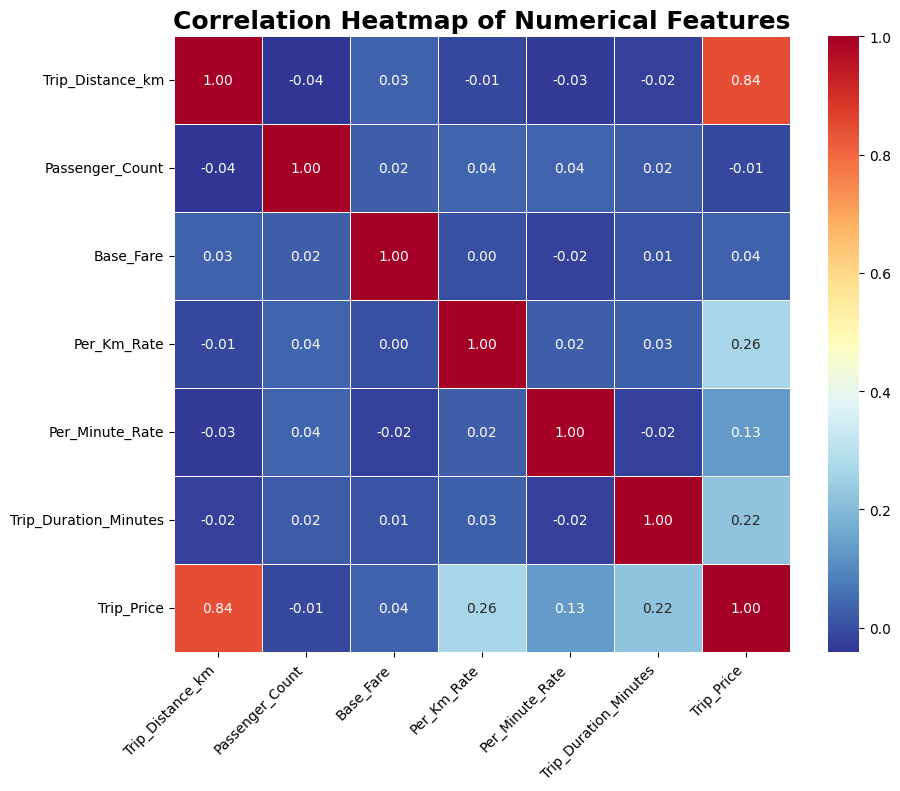

In [59]:
# Correlation Heatmap visualization code
# Chart 14: Correlation Heatmap

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={'size':10}
)

plt.title('Correlation Heatmap of Numerical Features',
          fontsize=18,
          fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

* A correlation heatmap is ideal for understanding the relationships between numerical variables.
* It helps identify features that have a strong positive or negative relationship with the target variable (Trip_Price).
* It provides a quick overview of how all numerical features interact with each other.

##### 2. What is/are the insight(s) found from the chart?

* The heatmap reveals the strength and direction of relationships between numerical features.
* Features with higher positive correlation to Trip_Price are likely to be more influential in predicting taxi fares.
* Features with very low correlation may contribute less to the prediction model.
* Highly correlated independent variables may indicate redundant information.

#### Chart - 15 - Pair Plot

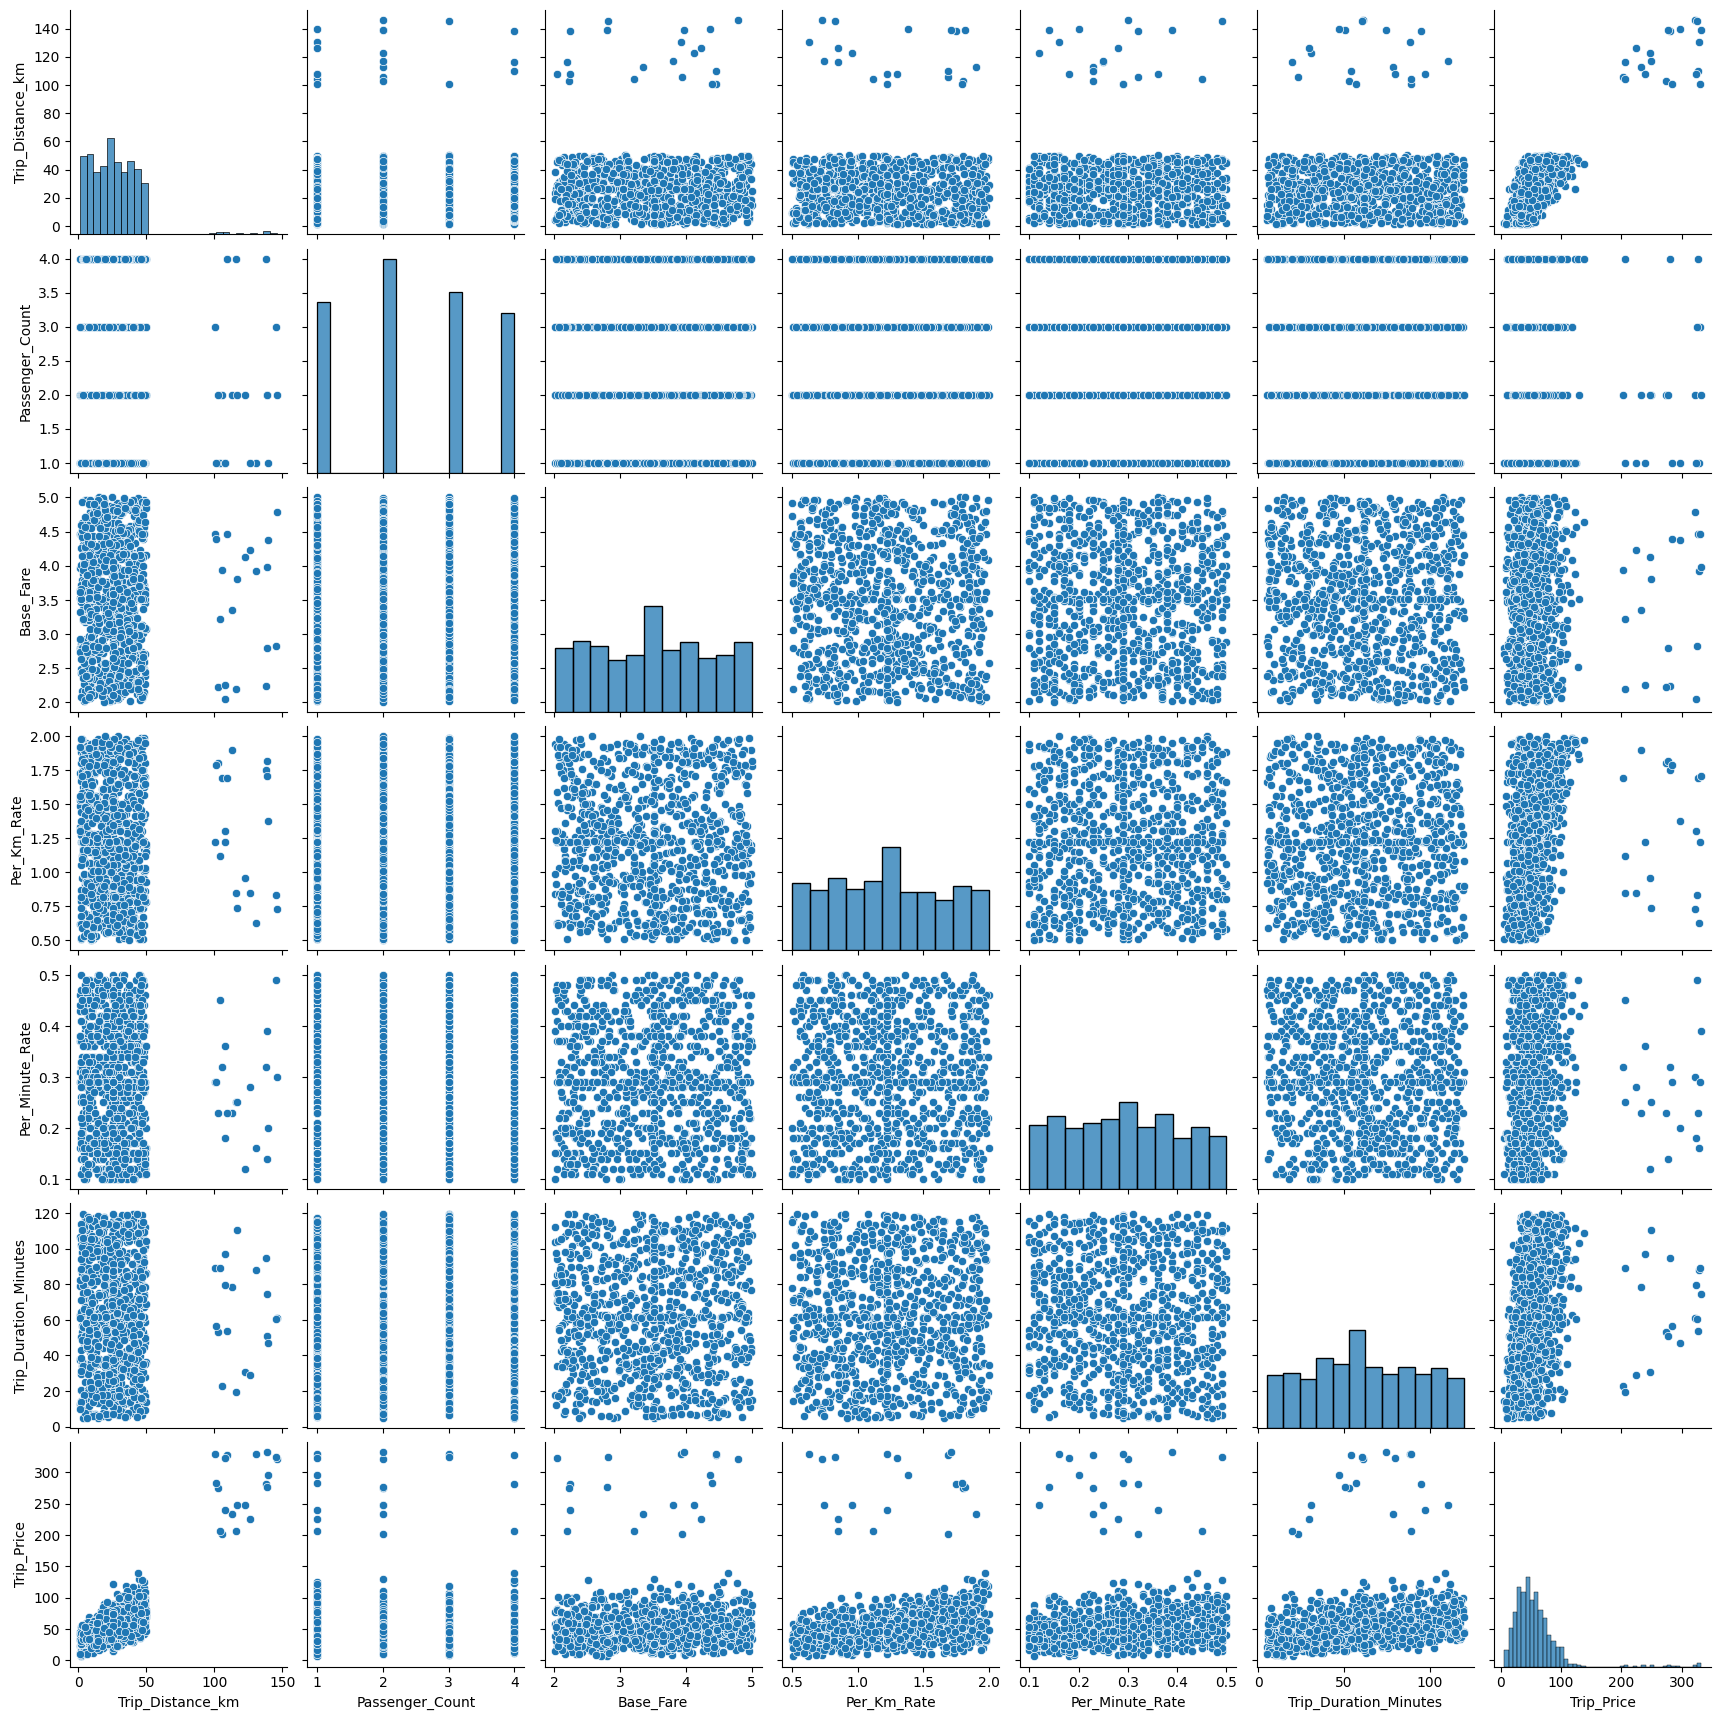

In [32]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [34]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [35]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [36]:
# Expand Contraction

#### 2. Lower Casing

In [37]:
# Lower Casing

#### 3. Removing Punctuations

In [38]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [39]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [40]:
# Remove Stopwords

In [41]:
# Remove White spaces

#### 6. Rephrase Text

In [42]:
# Rephrase Text

#### 7. Tokenization

In [43]:
# Tokenization

#### 8. Text Normalization

In [44]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [45]:
# POS Taging

#### 10. Text Vectorization

In [46]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [47]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [48]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [49]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [51]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [52]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [53]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [54]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [56]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [57]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***